# Humidity Data Diagnosis 與 Training Workflow

這份 notebook 使用 MySQL 中的 `humidity` 真實小時天氣資料。目標是先判斷資料 behavior 較接近哪一種類型，再選擇對應的 simulation case。整體 workflow 使用最近 7 天資料作為 rolling training window，並建立未來 24 小時的 forecasting setup。

## 1. 載入 Packages 與 Project Settings

這個 cell 會載入 paper-aligned workflow 需要的 packages。Machine Learning 部分改成 Super Learner-style stacking ensemble，base learners 對照 paper Table 1/2 中列出的 SVR、GBM、KNN、RF、Bagging、NN、ExtraTrees、DecisionTree 與 AdaBoost。Kriging 使用 `PyKrige` 的 Ordinary Kriging；Fusion weight 使用 `scipy.optimize` 的 SLSQP optimization。


In [1]:
from pathlib import Path
import sys
import importlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.spatial import cKDTree
from scipy.stats import skew, kurtosis
from sklearn.ensemble import (
    AdaBoostRegressor,
    BaggingRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from pykrige.ok import OrdinaryKriging

ROOT = Path.cwd().parent if Path.cwd().name == 'main' else Path.cwd()
sys.path.insert(0, str(ROOT / 'backend'))

import config as config_module
import db as db_module
importlib.reload(config_module)
importlib.reload(db_module)
settings = config_module.settings
read_observations = db_module.read_observations
read_observations_range = db_module.read_observations_range
upsert_predictions = db_module.upsert_predictions
ensure_predictions_schema = db_module.ensure_predictions_schema
get_connection = db_module.get_connection

sns.set_theme(style='whitegrid')
TRAINING_HOURS = 168
FORECAST_HOURS = 24
VARIABLE = 'humidity'
safe_db_settings = dict(config_module.db_settings)
safe_db_settings['password_set'] = bool(safe_db_settings.pop('password'))
print({'variable': VARIABLE, 'training_hours': TRAINING_HOURS, 'forecast_hours': FORECAST_HOURS})
print('db_settings:', safe_db_settings)


{'variable': 'humidity', 'training_hours': 168, 'forecast_hours': 24}
db_settings: {'server': '127.0.0.1', 'port': 3306, 'user': 'root', 'database': 'spatial', 'charset': 'utf8', 'password_set': True}


## 2. 從 MySQL 讀取最近 7 天資料

project database 會把真實 observation 存在 `observations_hourly`，測站座標存在 `stations`。這個 cell 固定讀取 `humidity` 的最近 168 小時資料，後續 diagnostic、training、rolling validation 與 prediction export 都會使用同一個 variable。

In [2]:
safe_db_settings = dict(config_module.db_settings)
safe_db_settings['password_set'] = bool(safe_db_settings.pop('password'))
print('db_settings:', safe_db_settings)

df = read_observations(VARIABLE, limit_hours=TRAINING_HOURS)

df['datetime'] = pd.to_datetime(df['datetime'])
df = (
    df.dropna(subset=['lat', 'lon', 'datetime', 'value'])
      .sort_values(['datetime', 'station_id'])
)
display(df.head())
print('rows:', len(df), 'stations:', df['station_id'].nunique(), 'time range:', df['datetime'].min(), 'to', df['datetime'].max())

db_settings: {'server': '127.0.0.1', 'port': 3306, 'user': 'root', 'database': 'spatial', 'charset': 'utf8', 'password_set': True}


c:\Users\User.DESKTOP-4RV84M1\Desktop\空間統計\期末\backend\db.py:62: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn, params=(limit_hours,))


,station_id,station_name,lat,lon,datetime,value
0,12J990,口湖工作站,23.589978,120.180394,2026-05-11 21:00:00,90.0
1,12Q970,東港工作站,22.479997,120.466058,2026-05-11 21:00:00,71.0
2,12Q980,恆春工作站,22.079678,120.714425,2026-05-11 21:00:00,83.0
3,42HA10,萬大發電廠,23.978875,121.139639,2026-05-11 21:00:00,87.0
4,466881,新北,24.959207,121.525196,2026-05-11 21:00:00,85.0


rows: 131292 stations: 838 time range: 2026-05-11 21:00:00 to 2026-05-18 21:00:00


## 3. 診斷 Data Type

paper 比較了不同 spatial data behavior，例如 Gaussian、complex/non-stationary、trend 與 lognormal cases。對 weather data 來說，可以用 skewness、log-skewness、temporal trend strength 與 spatial nonlinearity 來判斷最接近的 behavior。這不是嚴格定理，而是用來選擇 simulation case 的 practical rule。

{
  "case": "non_stationary",
  "skewness": -0.626432694449055,
  "kurtosis": -0.07653482201318651,
  "log1p_skewness_positive_values": -1.638124093137486,
  "temporal_trend_r2": 0.05509518114641698,
  "latest_hour_spatial_rf_r2": 0.24124808793761
}


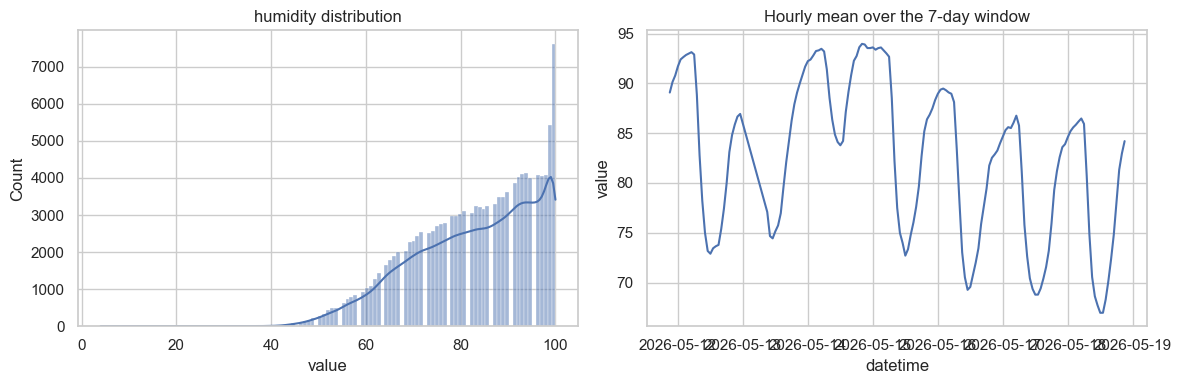

In [3]:
def diagnose_data_type(data):
    x = data['value'].astype(float).to_numpy()
    x_skew = float(skew(x, nan_policy='omit'))
    x_kurt = float(kurtosis(x, nan_policy='omit'))
    positive = x[x > 0]
    log_skew = float(skew(np.log1p(positive), nan_policy='omit')) if len(positive) else np.nan

    time_index = (data['datetime'] - data['datetime'].min()).dt.total_seconds().to_numpy().reshape(-1, 1)
    trend_model = LinearRegression().fit(time_index, x)
    trend_r2 = float(trend_model.score(time_index, x))

    latest = data[data['datetime'] == data['datetime'].max()].copy()
    spatial_r2 = np.nan
    if len(latest) >= 8:
        X = latest[['lon', 'lat']].to_numpy()
        y = latest['value'].to_numpy()
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)
        rf = RandomForestRegressor(n_estimators=200, random_state=42, min_samples_leaf=2)
        rf.fit(X_train, y_train)
        spatial_r2 = float(r2_score(y_test, rf.predict(X_test)))

    if abs(x_skew) < 0.5 and trend_r2 < 0.2:
        case = 'gaussian'
    elif x_skew > 1.0 and abs(log_skew) < abs(x_skew):
        case = 'skewed_lognormal'
    elif trend_r2 >= 0.25:
        case = 'trend'
    else:
        case = 'non_stationary'

    return {
        'case': case,
        'skewness': x_skew,
        'kurtosis': x_kurt,
        'log1p_skewness_positive_values': log_skew,
        'temporal_trend_r2': trend_r2,
        'latest_hour_spatial_rf_r2': spatial_r2,
    }

diagnosis = diagnose_data_type(df)
print(json.dumps(diagnosis, indent=2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['value'], kde=True, ax=axes[0])
axes[0].set_title(f'{VARIABLE} distribution')
hourly = df.groupby('datetime')['value'].mean().reset_index()
sns.lineplot(data=hourly, x='datetime', y='value', ax=axes[1])
axes[1].set_title('Hourly mean over the 7-day window')
plt.tight_layout()

## 3.1 補充 Diagnostic Figures

這一節用真實 weather data 補幾個診斷圖，協助判斷資料比較接近 paper 中的哪一種 behavior。因為真實 weather surface 不可完全觀測，這裡用 distribution、Q-Q plot、temporal trend、spatial scatter 與 empirical semivariogram 來做 evidence。


,distance,semivariance,pairs
0,0.234767,71.715617,7082
1,0.684162,108.598565,10871
2,1.133557,86.203014,11514
3,1.582952,96.063779,8310
4,2.032347,96.645045,5812


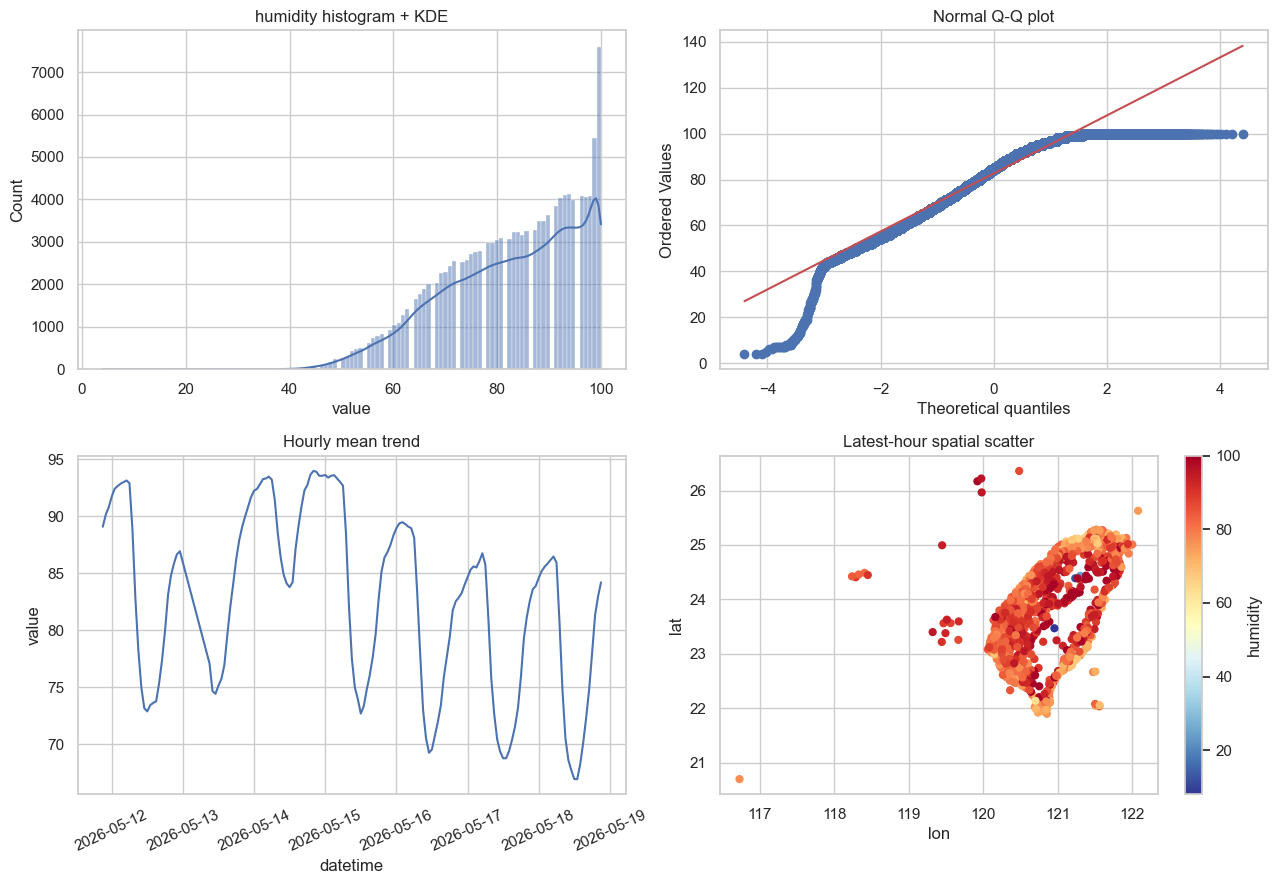

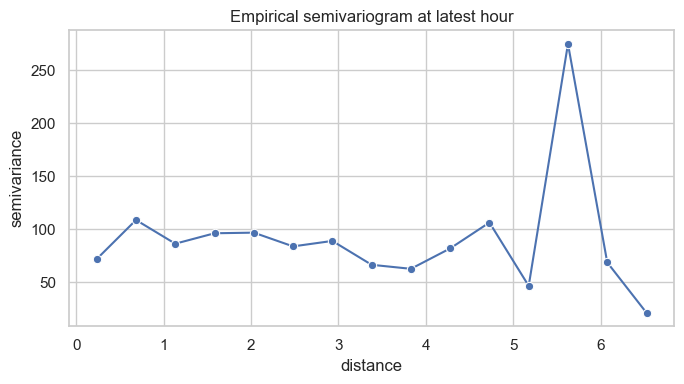

In [4]:
from scipy import stats

latest = df[df['datetime'] == df['datetime'].max()].copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(df['value'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title(f'{VARIABLE} histogram + KDE')

stats.probplot(df['value'].dropna(), dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q plot')

hourly_mean = df.groupby('datetime')['value'].mean().reset_index()
sns.lineplot(data=hourly_mean, x='datetime', y='value', ax=axes[1, 0])
axes[1, 0].set_title('Hourly mean trend')
axes[1, 0].tick_params(axis='x', rotation=25)

sc = axes[1, 1].scatter(latest['lon'], latest['lat'], c=latest['value'], cmap='RdYlBu_r', s=24)
axes[1, 1].set_title('Latest-hour spatial scatter')
axes[1, 1].set_xlabel('lon')
axes[1, 1].set_ylabel('lat')
plt.colorbar(sc, ax=axes[1, 1], label=VARIABLE)
plt.tight_layout()


def empirical_semivariogram(data, max_pairs=50000, n_bins=15, random_state=42):
    sample = data[['lon', 'lat', 'value']].dropna().copy()
    coords = sample[['lon', 'lat']].to_numpy(float)
    values = sample['value'].to_numpy(float)
    rng = np.random.default_rng(random_state)
    n = len(sample)
    if n < 3:
        return pd.DataFrame(columns=['distance', 'semivariance', 'pairs'])

    pair_count = min(max_pairs, n * (n - 1) // 2)
    i = rng.integers(0, n, pair_count)
    j = rng.integers(0, n, pair_count)
    valid = i != j
    i, j = i[valid], j[valid]
    distances = np.sqrt(((coords[i] - coords[j]) ** 2).sum(axis=1))
    semivar = 0.5 * (values[i] - values[j]) ** 2
    bins = np.linspace(distances.min(), distances.max(), n_bins + 1)
    labels = 0.5 * (bins[:-1] + bins[1:])
    binned = pd.cut(distances, bins=bins, labels=labels, include_lowest=True)
    out = pd.DataFrame({'distance_bin': binned, 'semivariance': semivar})
    return out.groupby('distance_bin', observed=True).agg(
        distance=('distance_bin', lambda x: float(x.iloc[0])),
        semivariance=('semivariance', 'mean'),
        pairs=('semivariance', 'size'),
    ).reset_index(drop=True)

variogram_df = empirical_semivariogram(latest)
display(variogram_df.head())
plt.figure(figsize=(7, 4))
sns.lineplot(data=variogram_df, x='distance', y='semivariance', marker='o')
plt.title('Empirical semivariogram at latest hour')
plt.xlabel('distance')
plt.ylabel('semivariance')
plt.tight_layout()


## 4. Ordinary Kriging、Super Learner 與 Fusion Model

這一節改成對照 paper 的主要流程：先用 Ordinary Kriging 取得 `Z_KR(u)` 與 Kriging variance，再逐一訓練 Super Learner 的 base learners，包含 SVR、GBM、KNN、RF、Bagging、NN、ExtraTrees、DecisionTree 與 AdaBoost。接著用 StackingRegressor 的 meta learner 估計各 base learner 的 stacking weight，產生 `Z_ML(u)`。最後使用 paper 的 weight formula：`w(u) = (sigma_KR^2(u))^b`，其中 `b = b0 + b1 * Z_KR(u)`，並用 SLSQP optimization 找出讓 holdout RMSE 最小的 `b0` 與 `b1`。


,base_learner,RMSE,MAE,R2
6,EXT,8.466740,5.569029,0.244892
4,BAG,8.535113,5.707756,0.232647
3,RF,8.540966,5.712551,0.231594
2,KNN,8.942616,5.975610,0.157624
8,ADA,9.482015,6.921301,0.052939
5,NN,9.761597,7.404387,-0.003734
0,SVR,9.777427,7.402989,-0.006992
7,DT,10.559365,6.964250,-0.174498
1,GBM,11.302359,7.113295,-0.345597


,base_learner,stacking_weight,abs_weight
5,NN,-1.602745,1.602745
3,RF,1.358839,1.358839
4,BAG,-0.824617,0.824617
2,KNN,0.222969,0.222969
8,ADA,-0.136656,0.136656
0,SVR,-0.112187,0.112187
6,EXT,-0.103784,0.103784
7,DT,0.090001,0.090001
1,GBM,0.006969,0.006969


{'success': np.True_, 'message': 'Optimization terminated successfully', 'best_b0': np.float64(0.08584370256584618), 'best_b1': np.float64(1.1995783315006359), 'best_rmse': 8.377713745506554}


,model,RMSE,MAE,R2
0,Ordinary Kriging,8.536355,6.223199,0.232423
1,Super Learner,8.417234,5.776971,0.253696
2,Optimized Fusion,8.377714,5.777948,0.260688


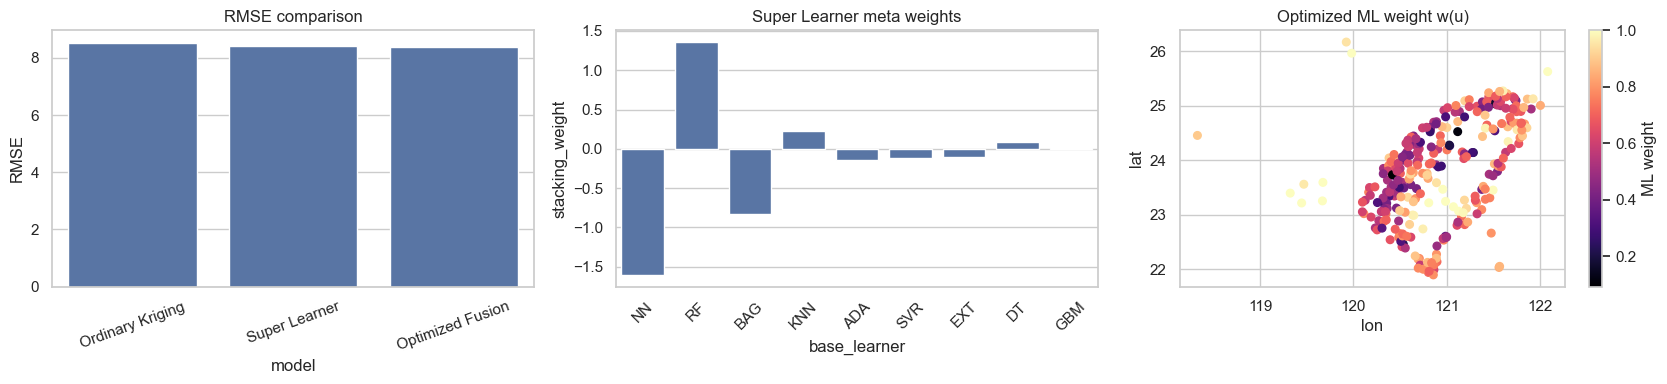

In [5]:
def ordinary_kriging_predict(train_xy, train_y, target_xy, variogram_model='spherical'):
    ok = OrdinaryKriging(
        train_xy[:, 0],
        train_xy[:, 1],
        train_y,
        variogram_model=variogram_model,
        verbose=False,
        enable_plotting=False,
    )
    pred, var = ok.execute('points', target_xy[:, 0], target_xy[:, 1])
    return np.asarray(pred, dtype=float), np.asarray(var, dtype=float)


def build_paper_super_learner(random_state=42):
    base_models = [
        ('SVR', SVR(kernel='rbf', gamma='scale', C=1e4, epsilon=0.01)),
        ('GBM', GradientBoostingRegressor(learning_rate=0.25, n_estimators=1000, min_samples_split=4, random_state=random_state)),
        ('KNN', KNeighborsRegressor(n_neighbors=2, p=2)),
        ('RF', RandomForestRegressor(n_estimators=2000, max_depth=None, min_samples_split=2, random_state=random_state, n_jobs=-1)),
        ('BAG', BaggingRegressor(n_estimators=3000, max_features=1.0, random_state=random_state, n_jobs=-1)),
        ('NN', MLPRegressor(hidden_layer_sizes=(10, 10), activation='relu', solver='adam', batch_size=80, max_iter=400, random_state=random_state)),
        ('EXT', ExtraTreesRegressor(n_estimators=2500, random_state=random_state, n_jobs=-1)),
        ('DT', DecisionTreeRegressor(max_depth=14, random_state=random_state)),
        ('ADA', AdaBoostRegressor(n_estimators=700, random_state=random_state)),
    ]
    return StackingRegressor(
        estimators=base_models,
        final_estimator=LinearRegression(),
        cv=5,
        n_jobs=-1,
        passthrough=False,
    )


def standardize_01(x):
    x = np.asarray(x, dtype=float)
    return (x - np.nanmin(x)) / max(float(np.nanmax(x) - np.nanmin(x)), 1e-9)


def fusion_prediction(kr_pred, kr_var, ml_pred, b0, b1):
    sigma = np.clip(standardize_01(kr_var), 1e-9, 1.0)
    z_scaled = standardize_01(kr_pred)
    b = np.clip(b0 + b1 * z_scaled, 0.01, 8.0)
    weight_ml = np.clip(sigma ** b, 0.0, 1.0)
    pred = weight_ml * ml_pred + (1.0 - weight_ml) * kr_pred
    return pred, weight_ml


def optimize_fusion_weight(y_true, kr_pred, kr_var, ml_pred):
    def objective(params):
        b0, b1 = params
        pred, _ = fusion_prediction(kr_pred, kr_var, ml_pred, b0, b1)
        return mean_squared_error(y_true, pred) ** 0.5

    result = minimize(
        objective,
        x0=np.array([1.0, 0.0]),
        method='SLSQP',
        bounds=[(0.01, 8.0), (-8.0, 8.0)],
        options={'maxiter': 300, 'ftol': 1e-9},
    )
    best_b0, best_b1 = result.x
    best_pred, best_weight = fusion_prediction(kr_pred, kr_var, ml_pred, best_b0, best_b1)
    return result, best_pred, best_weight

latest = df[df['datetime'] == df['datetime'].max()].copy()
train_sp, test_sp = train_test_split(latest, test_size=0.35, random_state=42)
X_train = train_sp[['lon', 'lat']].to_numpy(float)
y_train = train_sp['value'].to_numpy(float)
X_test = test_sp[['lon', 'lat']].to_numpy(float)
y_test = test_sp['value'].to_numpy(float)

kr_pred, kr_var = ordinary_kriging_predict(X_train, y_train, X_test)

super_learner = build_paper_super_learner(random_state=42)
super_learner.fit(X_train, y_train)
ml_pred = super_learner.predict(X_test)

base_results = []
for name, estimator in super_learner.named_estimators_.items():
    pred = estimator.predict(X_test)
    base_results.append({
        'base_learner': name,
        'RMSE': mean_squared_error(y_test, pred) ** 0.5,
        'MAE': mean_absolute_error(y_test, pred),
        'R2': r2_score(y_test, pred),
    })
base_results = pd.DataFrame(base_results).sort_values('RMSE')
display(base_results)

meta_weights = pd.DataFrame({
    'base_learner': list(super_learner.named_estimators_.keys()),
    'stacking_weight': super_learner.final_estimator_.coef_,
})
meta_weights['abs_weight'] = meta_weights['stacking_weight'].abs()
meta_weights = meta_weights.sort_values('abs_weight', ascending=False)
display(meta_weights)

opt_result, fusion_pred, fusion_weight = optimize_fusion_weight(y_test, kr_pred, kr_var, ml_pred)
print({'success': opt_result.success, 'message': opt_result.message, 'best_b0': opt_result.x[0], 'best_b1': opt_result.x[1], 'best_rmse': opt_result.fun})

def metrics(name, pred):
    return {
        'model': name,
        'RMSE': mean_squared_error(y_test, pred) ** 0.5,
        'MAE': mean_absolute_error(y_test, pred),
        'R2': r2_score(y_test, pred),
    }

results = pd.DataFrame([
    metrics('Ordinary Kriging', kr_pred),
    metrics('Super Learner', ml_pred),
    metrics('Optimized Fusion', fusion_pred),
])
display(results)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.barplot(data=results, x='model', y='RMSE', ax=axes[0])
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_title('RMSE comparison')
sns.barplot(data=meta_weights, x='base_learner', y='stacking_weight', ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Super Learner meta weights')
sc = axes[2].scatter(test_sp['lon'], test_sp['lat'], c=fusion_weight, cmap='magma', s=30)
axes[2].set_title('Optimized ML weight w(u)')
axes[2].set_xlabel('lon')
axes[2].set_ylabel('lat')
plt.colorbar(sc, ax=axes[2], label='ML weight')
plt.tight_layout()


## 4.1 Rolling Spatial Holdout Validation 並寫入 predictions_hourly

這一節使用指定時間範圍 `2026-04-13 10:00` 到 `2026-05-18 21:00` 的 `observations_hourly`。每一個 hour 都會做一次 70/30 station holdout：70% stations 用來訓練 Ordinary Kriging 與 Super Learner，30% stations 當作 testing stations。因為 testing stations 有真實 observation，所以可以計算每個 hour 的 RMSE/MAE/R²。結果同時比較 Ordinary Kriging、Super Learner、Fixed 1/2 Fusion 與 Optimized Fusion，並把 testing stations 的 prediction 寫入 `predictions_hourly`。


In [6]:
from pathlib import Path
import sys

if 'ROOT' not in globals():
    ROOT = Path.cwd().parent if Path.cwd().name == 'main' else Path.cwd()
    sys.path.insert(0, str(ROOT / 'backend'))

if 'VARIABLE' not in globals():
    VARIABLE = 'humidity'

ROLLING_START = '2026-04-13 10:00:00'
ROLLING_END = '2026-05-18 21:00:00'
HOLDOUT_TEST_SIZE = 0.30
ROLLING_RANDOM_STATE = 42

# 如果要先快速測試，設成例如 5；正式報告請設成 None。
ROLLING_MAX_HOURS = None

# True 會略過 predictions_hourly 已經有的 datetime，適合中斷後續跑。
# 如果你要重算完整 RMSE comparison table，改成 False 從頭重跑。
SKIP_EXISTING_PREDICTIONS = False

ROLLING_METRICS_CSV = ROOT / 'main' / f'rolling_metrics_{VARIABLE}.csv'

range_df = read_observations_range(VARIABLE, ROLLING_START, ROLLING_END)
range_df['datetime'] = pd.to_datetime(range_df['datetime'])
range_df = range_df.dropna(subset=['lat', 'lon', 'datetime', 'value']).sort_values(['datetime', 'station_id'])
print('range rows:', len(range_df), 'hours:', range_df['datetime'].nunique(), 'stations:', range_df['station_id'].nunique())

ensure_predictions_schema()

def get_existing_prediction_hours(variable, start_datetime, end_datetime):
    conn = get_connection()
    try:
        query = """
            SELECT DISTINCT target_datetime
            FROM predictions_hourly
            WHERE variable_name = %s
              AND target_datetime BETWEEN %s AND %s
        """
        existing = pd.read_sql(query, conn, params=(variable, start_datetime, end_datetime))
    finally:
        conn.close()
    if existing.empty:
        return set()
    return set(pd.to_datetime(existing['target_datetime']))

def append_metrics_csv(metric_rows, csv_path):
    metric_df = pd.DataFrame(metric_rows)
    metric_df.to_csv(csv_path, mode='a', header=not csv_path.exists(), index=False, encoding='utf-8-sig')

def fit_predict_one_hour(hour_df, random_state=42):
    if len(hour_df) < 10:
        return None, [], None

    train_sp, test_sp = train_test_split(hour_df, test_size=HOLDOUT_TEST_SIZE, random_state=random_state)
    X_train = train_sp[['lon', 'lat']].to_numpy(float)
    y_train = train_sp['value'].to_numpy(float)
    X_test = test_sp[['lon', 'lat']].to_numpy(float)
    y_test = test_sp['value'].to_numpy(float)

    kr_pred, kr_var = ordinary_kriging_predict(X_train, y_train, X_test)

    super_learner = build_paper_super_learner(random_state=random_state)
    super_learner.fit(X_train, y_train)
    ml_pred = super_learner.predict(X_test)

    fixed_half_pred = 0.5 * ml_pred + 0.5 * kr_pred
    opt_result, optimized_fusion_pred, optimized_weight = optimize_fusion_weight(y_test, kr_pred, kr_var, ml_pred)

    def row_metrics(model_name, pred):
        return {
            'datetime': hour_df['datetime'].iloc[0],
            'model': model_name,
            'RMSE': mean_squared_error(y_test, pred) ** 0.5,
            'MAE': mean_absolute_error(y_test, pred),
            'R2': r2_score(y_test, pred),
            'n_train': len(train_sp),
            'n_test': len(test_sp),
            'best_b0': float(opt_result.x[0]),
            'best_b1': float(opt_result.x[1]),
        }

    metric_rows = [
        row_metrics('Ordinary Kriging', kr_pred),
        row_metrics('Super Learner', ml_pred),
        row_metrics('Fixed 1/2 Fusion', fixed_half_pred),
        row_metrics('Optimized Fusion', optimized_fusion_pred),
    ]

    # RMSE 使用 holdout test stations；寫入 app / predictions_hourly 時，則輸出該小時所有 stations。
    X_all = hour_df[['lon', 'lat']].to_numpy(float)
    kr_pred_all, kr_var_all = ordinary_kriging_predict(X_train, y_train, X_all)
    ml_pred_all = super_learner.predict(X_all)
    fixed_half_pred_all = 0.5 * ml_pred_all + 0.5 * kr_pred_all
    optimized_fusion_pred_all, optimized_weight_all = fusion_prediction(
        kr_pred_all,
        kr_var_all,
        ml_pred_all,
        float(opt_result.x[0]),
        float(opt_result.x[1]),
    )

    train_ids = set(train_sp['station_id'].astype(str))
    test_ids = set(test_sp['station_id'].astype(str))
    prediction_rows = []
    all_reset = hour_df.reset_index(drop=True)
    for idx, row in all_reset.iterrows():
        station_id = str(row['station_id'])
        split_role = 'test' if station_id in test_ids else 'train' if station_id in train_ids else 'unknown'
        prediction_rows.append({
            'target_datetime': row['datetime'].to_pydatetime(),
            'lat': float(row['lat']),
            'lon': float(row['lon']),
            'variable_name': VARIABLE,
            'kriging_pred': float(kr_pred_all[idx]),
            'ml_pred': float(ml_pred_all[idx]),
            'fixed_half_pred': float(fixed_half_pred_all[idx]),
            'fusion_pred': float(optimized_fusion_pred_all[idx]),
            'ar_pred': None,
            'kriging_variance': float(kr_var_all[idx]),
            'model_name': 'RollingHoldoutAllStations: OrdinaryKriging+SuperLearner+OptimizedFusion',
            'model_info': json.dumps({
                'validation': '70/30 station holdout for RMSE; all stations exported for app surface',
                'split_role': split_role,
                'station_id': station_id,
                'source_table': 'observations_hourly',
                'fixed_half_formula': '0.5 * Z_ML + 0.5 * Z_KR',
                'optimized_weight_formula': 'w(u) = standardized_sigma_KR2(u) ** (b0 + b1 * standardized_Z_KR(u))',
                'best_b0': float(opt_result.x[0]),
                'best_b1': float(opt_result.x[1]),
                'slsqp_success': bool(opt_result.success),
            }, ensure_ascii=False),
        })

    return metric_rows, prediction_rows, opt_result

all_metric_rows = []
all_prediction_rows = []
hours = list(range_df['datetime'].drop_duplicates().sort_values())
if ROLLING_MAX_HOURS is not None:
    hours = hours[:ROLLING_MAX_HOURS]

existing_hours = get_existing_prediction_hours(VARIABLE, ROLLING_START, ROLLING_END)
print('target hours:', len(hours), 'already stored hours:', len(existing_hours), 'skip existing:', SKIP_EXISTING_PREDICTIONS)

for hour_idx, current_time in enumerate(hours, start=1):
    current_time = pd.Timestamp(current_time)
    if SKIP_EXISTING_PREDICTIONS and current_time in existing_hours:
        print(f'[{hour_idx}/{len(hours)}] {current_time} skipped, already in predictions_hourly')
        continue

    hour_df = range_df[range_df['datetime'] == current_time].copy()
    metric_rows, prediction_rows, opt_result = fit_predict_one_hour(hour_df, random_state=ROLLING_RANDOM_STATE + hour_idx)
    if metric_rows is None:
        continue

    affected = upsert_predictions(prediction_rows) if prediction_rows else 0
    append_metrics_csv(metric_rows, ROLLING_METRICS_CSV)
    existing_hours.add(current_time)
    all_metric_rows.extend(metric_rows)
    all_prediction_rows.extend(prediction_rows)
    print(f'[{hour_idx}/{len(hours)}] {current_time} done, predictions={len(prediction_rows)}, affected={affected}')

rolling_metrics_current = pd.DataFrame(all_metric_rows)
if not rolling_metrics_current.empty:
    display(rolling_metrics_current.head())

if ROLLING_METRICS_CSV.exists():
    rolling_metrics = pd.read_csv(ROLLING_METRICS_CSV, parse_dates=['datetime'])
    rolling_metrics = rolling_metrics.drop_duplicates(subset=['datetime', 'model'], keep='last')
else:
    rolling_metrics = rolling_metrics_current

print('stored prediction rows this run:', len(all_prediction_rows))
print('metrics csv:', ROLLING_METRICS_CSV)
print('metrics hours available:', rolling_metrics['datetime'].nunique() if not rolling_metrics.empty else 0)

rmse_comparison_table = (
    rolling_metrics
    .groupby('model')
    .agg(
        mean_RMSE=('RMSE', 'mean'),
        std_RMSE=('RMSE', 'std'),
        min_RMSE=('RMSE', 'min'),
        max_RMSE=('RMSE', 'max'),
        mean_MAE=('MAE', 'mean'),
        mean_R2=('R2', 'mean'),
        n_hours=('datetime', 'nunique'),
    )
    .sort_values('mean_RMSE')
)
display(rmse_comparison_table)

rmse_wide = (
    rolling_metrics
    .pivot_table(index='datetime', columns='model', values='RMSE', aggfunc='mean')
    .sort_index()
)
display(rmse_wide.head())


c:\Users\User.DESKTOP-4RV84M1\Desktop\空間統計\期末\backend\db.py:87: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn, params=(start_datetime, end_datetime))


range rows: 657220 hours: 801 stations: 838


C:\Users\User.DESKTOP-4RV84M1\AppData\Local\Temp\ipykernel_12592\3243386342.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  existing = pd.read_sql(query, conn, params=(variable, start_datetime, end_datetime))


target hours: 801 already stored hours: 145 skip existing: False
[1/801] 2026-04-13 10:00:00 done, predictions=822, affected=822
[2/801] 2026-04-13 11:00:00 done, predictions=817, affected=817
[3/801] 2026-04-13 12:00:00 done, predictions=823, affected=823
[4/801] 2026-04-13 13:00:00 done, predictions=821, affected=821
[5/801] 2026-04-13 14:00:00 done, predictions=816, affected=816
[6/801] 2026-04-13 15:00:00 done, predictions=823, affected=823
[7/801] 2026-04-13 16:00:00 done, predictions=825, affected=825
[8/801] 2026-04-13 17:00:00 done, predictions=825, affected=825
[9/801] 2026-04-13 18:00:00 done, predictions=824, affected=824
[10/801] 2026-04-13 19:00:00 done, predictions=823, affected=823
[11/801] 2026-04-13 20:00:00 done, predictions=826, affected=826
[12/801] 2026-04-13 21:00:00 done, predictions=825, affected=825
[13/801] 2026-04-13 22:00:00 done, predictions=824, affected=824
[14/801] 2026-04-13 23:00:00 done, predictions=824, affected=824
[15/801] 2026-04-14 00:00:00 done,

c:\Users\User.DESKTOP-4RV84M1\miniconda3\envs\31011\lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\User.DESKTOP-4RV84M1\miniconda3\envs\31011\lib\site-packages\scipy\optimize\_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)


...

[794/801] 2026-05-18 14:00:00 done, predictions=819, affected=819
[795/801] 2026-05-18 15:00:00 done, predictions=820, affected=820
[796/801] 2026-05-18 16:00:00 done, predictions=819, affected=819
[797/801] 2026-05-18 17:00:00 done, predictions=821, affected=821
[798/801] 2026-05-18 18:00:00 done, predictions=821, affected=821
[799/801] 2026-05-18 19:00:00 done, predictions=820, affected=820
[800/801] 2026-05-18 20:00:00 done, predictions=822, affected=822
[801/801] 2026-05-18 21:00:00 done, predictions=820, affected=820


,datetime,model,RMSE,MAE,R2,n_train,n_test,best_b0,best_b1
0,2026-04-13 10:00:00,Ordinary Kriging,6.824778,5.150134,0.518453,575,247,0.01000,0.483800
1,2026-04-13 10:00:00,Super Learner,6.861172,5.332219,0.513303,575,247,0.01000,0.483800
2,2026-04-13 10:00:00,Fixed 1/2 Fusion,6.711233,5.099743,0.534343,575,247,0.01000,0.483800
3,2026-04-13 10:00:00,Optimized Fusion,6.637824,5.031514,0.544474,575,247,0.01000,0.483800
4,2026-04-13 11:00:00,Ordinary Kriging,7.401101,5.784717,0.573707,571,246,0.10346,0.240475


stored prediction rows this run: 657220
metrics csv: c:\Users\User.DESKTOP-4RV84M1\Desktop\空間統計\期末\main\rolling_metrics_humidity.csv
metrics hours available: 801


,mean_RMSE,std_RMSE,min_RMSE,max_RMSE,mean_MAE,mean_R2,n_hours
model,,,,,,,
Optimized Fusion,6.542022,1.588083,3.256898,13.462894,4.885910,0.529088,801
Super Learner,6.683679,1.610459,3.405094,13.106367,4.976558,0.507429,801
Fixed 1/2 Fusion,6.743200,1.708416,3.257799,14.361237,5.062160,0.502725,801
Ordinary Kriging,7.261942,2.252581,3.240202,16.311735,5.461838,0.422739,801


model,Fixed 1/2 Fusion,Optimized Fusion,Ordinary Kriging,Super Learner
datetime,,,,
2026-04-13 10:00:00,6.711233,6.637824,6.824778,6.861172
2026-04-13 11:00:00,7.319704,7.299368,7.401101,7.485545
2026-04-13 12:00:00,7.720482,7.669458,8.013950,7.737884
2026-04-13 13:00:00,8.094527,7.797567,8.978745,7.802684
2026-04-13 14:00:00,7.365000,7.336823,7.426384,7.541072


## 4.2 Rolling RMSE Comparison Plot

視覺化圖形讀取 `rolling_metrics_humidity.csv` ，輸出四種 model 的 RMSE comparison table，並把四條 RMSE line plot 疊在同一張圖。x-axis datetime 以半個月為主要刻度。


,mean_RMSE,std_RMSE,min_RMSE,max_RMSE,mean_MAE,mean_R2,n_hours
model,,,,,,,
Optimized Fusion,6.558599,1.574292,3.256898,13.462894,4.900162,0.531903,768
Super Learner,6.699413,1.593195,3.405094,13.106367,4.991084,0.510416,768
Fixed 1/2 Fusion,6.760221,1.695037,3.257799,14.361237,5.075980,0.505668,768
Ordinary Kriging,7.278076,2.238638,3.240202,16.311735,5.475884,0.426525,768


model,Fixed 1/2 Fusion,Optimized Fusion,Ordinary Kriging,Super Learner
datetime,,,,
2026-04-13 10:00:00,6.711233,6.637824,6.824778,6.861172
2026-04-13 11:00:00,7.319704,7.299368,7.401101,7.485545
2026-04-13 12:00:00,7.720482,7.669458,8.013950,7.737884
2026-04-13 13:00:00,8.094527,7.797567,8.978745,7.802684
2026-04-13 14:00:00,7.365000,7.336823,7.426384,7.541072


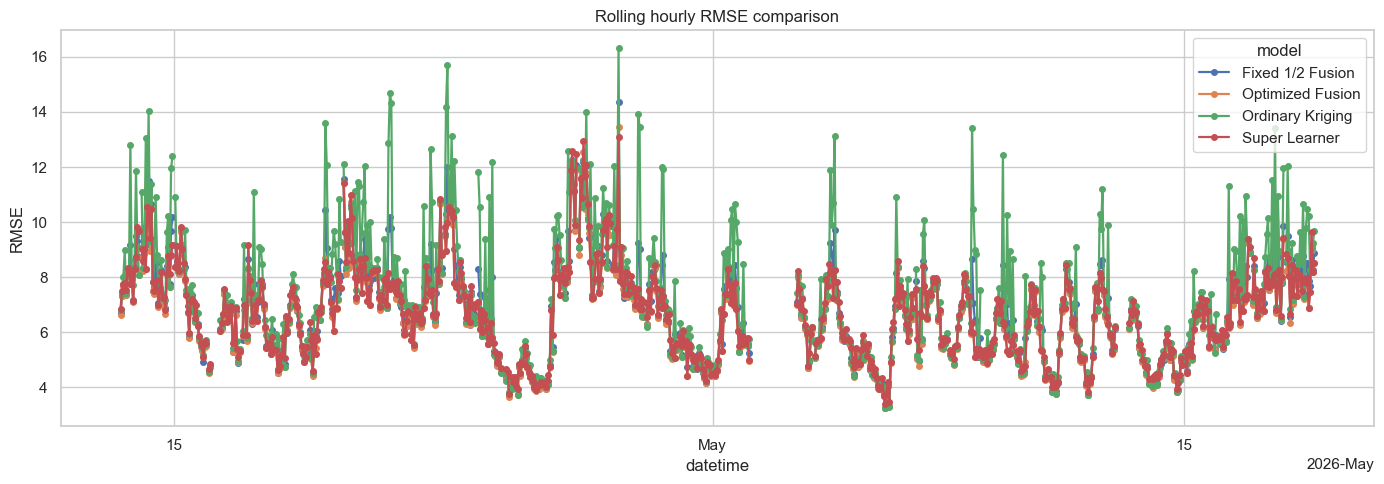

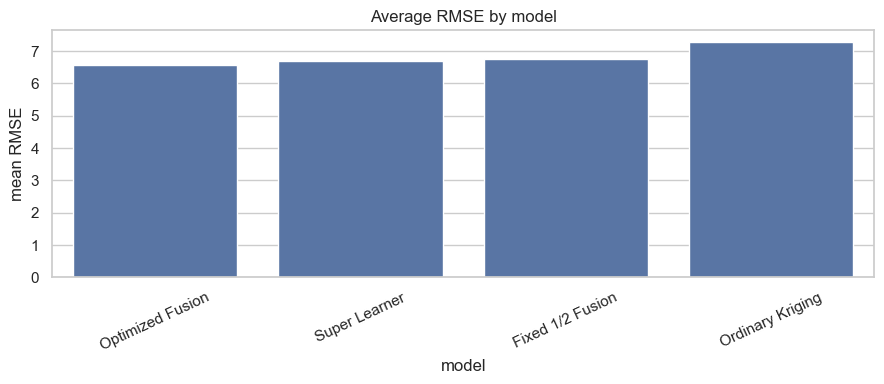

In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

if 'ROOT' not in globals():
    ROOT = Path.cwd().parent if Path.cwd().name == 'main' else Path.cwd()
if 'VARIABLE' not in globals():
    VARIABLE = 'humidity'

metrics_path = ROOT / 'main' / f'rolling_metrics_{VARIABLE}.csv'
if 'rolling_metrics' not in globals() or rolling_metrics.empty:
    rolling_metrics = pd.read_csv(metrics_path, parse_dates=['datetime'])

rolling_metrics['datetime'] = pd.to_datetime(rolling_metrics['datetime'], errors='coerce')
rolling_metrics = (
    rolling_metrics
    .dropna(subset=['datetime'])
    .drop_duplicates(subset=['datetime', 'model'], keep='last')
    .sort_values('datetime')
)

rmse_comparison_table = (
    rolling_metrics
    .groupby('model')
    .agg(
        mean_RMSE=('RMSE', 'mean'),
        std_RMSE=('RMSE', 'std'),
        min_RMSE=('RMSE', 'min'),
        max_RMSE=('RMSE', 'max'),
        mean_MAE=('MAE', 'mean'),
        mean_R2=('R2', 'mean'),
        n_hours=('datetime', 'nunique'),
    )
    .sort_values('mean_RMSE')
)
display(rmse_comparison_table)

rmse_wide = (
    rolling_metrics
    .pivot_table(index='datetime', columns='model', values='RMSE', aggfunc='mean')
    .sort_index()
)
display(rmse_wide.head())

def add_time_segments(metric_df, expected_gap='1h'):
    expected_gap = pd.Timedelta(expected_gap)
    metric_df = metric_df.sort_values(['model', 'datetime']).copy()
    metric_df['segment'] = (
        metric_df.groupby('model')['datetime']
        .diff()
        .gt(expected_gap)
        .groupby(metric_df['model'])
        .cumsum()
        .astype(int)
    )
    return metric_df

plot_metrics = add_time_segments(rolling_metrics, expected_gap='1h')

fig, ax = plt.subplots(figsize=(14, 5))
palette = dict(zip(plot_metrics['model'].drop_duplicates(), sns.color_palette(n_colors=plot_metrics['model'].nunique())))
for model_name, model_df in plot_metrics.groupby('model', sort=False):
    first_segment = True
    for _, segment_df in model_df.groupby('segment', sort=False):
        label = model_name if first_segment else '_nolegend_'
        ax.plot(
            segment_df['datetime'],
            segment_df['RMSE'],
            marker='o',
            linewidth=1.6,
            markersize=4,
            color=palette[model_name],
            label=label,
        )
        first_segment = False

ax.set_title('Rolling hourly RMSE comparison')
ax.set_xlabel('datetime')
ax.set_ylabel('RMSE')
locator = mdates.AutoDateLocator(minticks=3, maxticks=6)
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='model', loc='best')
plt.tight_layout()

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=rmse_comparison_table.reset_index(), x='model', y='mean_RMSE', ax=ax)
ax.set_title('Average RMSE by model')
ax.set_xlabel('model')
ax.set_ylabel('mean RMSE')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()


## 5. Global Spatio-Temporal ML Forecasting

原本 station-wise local AR 改成 global spatio-temporal model。模型不再替每個 station 各自選 AR lag，而是把所有 station 的資料合在一起，用同一個 global model 學習 `lon`、`lat`、`lag_1` 到 `lag_24`、`hour_of_day` 與 `day_of_week` 對下一小時 `value_t` 的影響。整張平面共用一個時空預測模型。


spatio-temporal supervised rows: 111220 stations: 836


,station_id,datetime,lat,lon,hour_of_day,day_of_week,value,lag_1,lag_2,lag_3,...,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24
0,12J990,2026-05-12 21:00:00,23.589978,120.180394,21,1,84.0,86.0,81.0,80.0,...,93.0,93.0,94.0,91.0,92.0,93.0,93.0,91.0,90.0,90.0
1,12J990,2026-05-12 22:00:00,23.589978,120.180394,22,1,84.0,84.0,86.0,81.0,...,90.0,93.0,93.0,94.0,91.0,92.0,93.0,93.0,91.0,90.0
2,12J990,2026-05-12 23:00:00,23.589978,120.180394,23,1,89.0,84.0,84.0,86.0,...,79.0,90.0,93.0,93.0,94.0,91.0,92.0,93.0,93.0,91.0
3,12J990,2026-05-13 09:00:00,23.589978,120.180394,9,2,75.0,89.0,84.0,84.0,...,77.0,79.0,90.0,93.0,93.0,94.0,91.0,92.0,93.0,93.0
4,12J990,2026-05-13 10:00:00,23.589978,120.180394,10,2,69.0,75.0,89.0,84.0,...,73.0,77.0,79.0,90.0,93.0,93.0,94.0,91.0,92.0,93.0


,model,RMSE,MAE,R2,n_train,n_test,test_hours
0,Global Spatio-Temporal RF,4.2225,2.822817,0.891199,91520,19700,24


,feature,importance
4,lag_1,0.887452
2,hour_of_day,0.024168
1,lat,0.007860
0,lon,0.005960
5,lag_2,0.005023
6,lag_3,0.004418
3,day_of_week,0.004162
27,lag_24,0.004008
24,lag_21,0.003622
7,lag_4,0.003524


,datetime,RMSE,MAE
0,2026-05-17 22:00:00,3.776862,1.882364
1,2026-05-17 23:00:00,4.079081,2.001170
2,2026-05-18 00:00:00,3.517111,2.033160
3,2026-05-18 01:00:00,3.796215,2.042520
4,2026-05-18 02:00:00,3.055152,1.935677


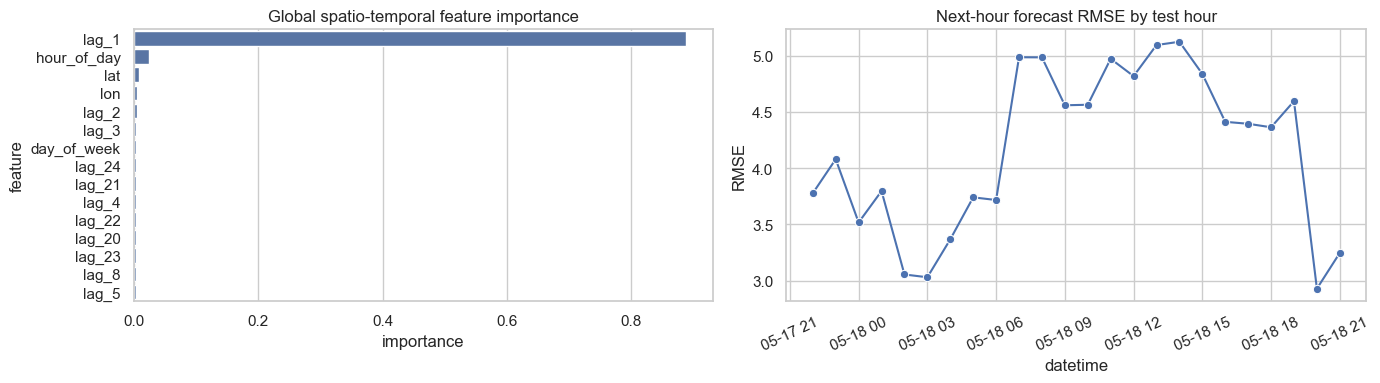

In [8]:
from sklearn.inspection import permutation_importance

GLOBAL_LAG_HOURS = 24
TEMPORAL_TEST_HOURS = 24


def build_spatiotemporal_supervised(data, max_lag=24):
    rows = []
    data = data.sort_values(['station_id', 'datetime']).copy()
    for station_id, group in data.groupby('station_id'):
        group = group.sort_values('datetime').reset_index(drop=True)
        values = group['value'].astype(float).to_numpy()
        for idx in range(max_lag, len(group)):
            row = {
                'station_id': station_id,
                'datetime': group.loc[idx, 'datetime'],
                'lat': float(group.loc[idx, 'lat']),
                'lon': float(group.loc[idx, 'lon']),
                'hour_of_day': int(group.loc[idx, 'datetime'].hour),
                'day_of_week': int(group.loc[idx, 'datetime'].dayofweek),
                'value': float(values[idx]),
            }
            for lag in range(1, max_lag + 1):
                row[f'lag_{lag}'] = float(values[idx - lag])
            rows.append(row)
    return pd.DataFrame(rows)

st_df = build_spatiotemporal_supervised(df, max_lag=GLOBAL_LAG_HOURS)
print('spatio-temporal supervised rows:', len(st_df), 'stations:', st_df['station_id'].nunique())
display(st_df.head())

feature_cols = ['lon', 'lat', 'hour_of_day', 'day_of_week'] + [f'lag_{lag}' for lag in range(1, GLOBAL_LAG_HOURS + 1)]
st_df = st_df.dropna(subset=feature_cols + ['value']).sort_values('datetime')

unique_times = sorted(st_df['datetime'].unique())
test_times = unique_times[-TEMPORAL_TEST_HOURS:]
train_st = st_df[~st_df['datetime'].isin(test_times)].copy()
test_st = st_df[st_df['datetime'].isin(test_times)].copy()

X_train = train_st[feature_cols].to_numpy(float)
y_train = train_st['value'].to_numpy(float)
X_test = test_st[feature_cols].to_numpy(float)
y_test = test_st['value'].to_numpy(float)

# Global model: one model learns all stations and all times together.
global_st_model = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
global_st_model.fit(X_train, y_train)
st_pred = global_st_model.predict(X_test)

st_metrics = pd.DataFrame([
    {
        'model': 'Global Spatio-Temporal RF',
        'RMSE': mean_squared_error(y_test, st_pred) ** 0.5,
        'MAE': mean_absolute_error(y_test, st_pred),
        'R2': r2_score(y_test, st_pred),
        'n_train': len(train_st),
        'n_test': len(test_st),
        'test_hours': TEMPORAL_TEST_HOURS,
    }
])
display(st_metrics)

importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': global_st_model.feature_importances_,
}).sort_values('importance', ascending=False)
display(importance.head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=importance.head(15), x='importance', y='feature', ax=axes[0])
axes[0].set_title('Global spatio-temporal feature importance')

plot_df = test_st[['datetime', 'station_id', 'value']].copy()
plot_df['prediction'] = st_pred
hourly_eval = plot_df.groupby('datetime').apply(
    lambda g: pd.Series({
        'RMSE': mean_squared_error(g['value'], g['prediction']) ** 0.5,
        'MAE': mean_absolute_error(g['value'], g['prediction']),
    }),
    include_groups=False,
).reset_index()
sns.lineplot(data=hourly_eval, x='datetime', y='RMSE', marker='o', ax=axes[1])
axes[1].set_title('Next-hour forecast RMSE by test hour')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()

display(hourly_eval.head())
